# Конспект 19.1 — Детекция объектов: интерактивная версия

Этот ноутбук — самодостаточный конспект ключевых концепций детекции объектов:

1. Anchor-based одностадийные детекторы и `AnchorGenerator`.
2. Метрика IoU и реализация вручную vs `torchvision.ops.box_iou`.
3. Лосс DIoU, формула и сравнение с `distance_box_iou_loss`.
4. TAL (Task Alignment Learning) — демонстрация на синтетическом примере.
5. NMS — фильтрация дубликатов через `torchvision.ops.nms`.
6. Сборка backbone через `timm.create_model(features_only=True)`.

**Полезные ссылки** (читать после ноутбука):

- [FPN](https://arxiv.org/abs/1612.03144), [PANet](https://arxiv.org/abs/1803.01534), [YOLOX](https://arxiv.org/abs/2107.08430), [TOOD/TAL](https://arxiv.org/abs/2108.07755), [DIoU](https://arxiv.org/abs/1911.08287)
- [torchvision.ops](https://pytorch.org/vision/main/ops.html), [torchmetrics MeanAveragePrecision](https://torchmetrics.readthedocs.io/en/stable/detection/mean_average_precision.html)
- [COCO Detection Eval](https://cocodataset.org/#detection-eval)


## 0. Импорты

In [1]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.ops import box_iou, nms, distance_box_iou_loss, generalized_box_iou
from torchvision.models.detection.anchor_utils import AnchorGenerator

torch.manual_seed(42)
np.random.seed(42)
print('torch:', torch.__version__)


torch: 2.11.0


## 1. Anchor-based детекторы — что такое якоря и зачем они нужны

Якорь — заранее заданный «шаблонный» прямоугольник на сетке предсказаний. На каждой ячейке feature-map (например, 80x80 при stride=8) располагается несколько якорей разных размеров и пропорций. Сеть для каждого якоря предсказывает смещение, класс и (опционально) confidence.

Используем `AnchorGenerator` из torchvision и нарисуем якоря для упрощённого случая: одна сетка 8x8, размер картинки 256x256, stride=32, 3 размера x 3 пропорции = 9 якорей в каждой ячейке.

In [2]:
# Сгенерируем якоря на сетке 8x8 (картинка 256x256, stride=32).
gen = AnchorGenerator(sizes=((48, 96, 192),), aspect_ratios=((0.5, 1.0, 2.0),))
anchors_list = gen.grid_anchors(grid_sizes=[[8, 8]], strides=[[32, 32]])
anchors = anchors_list[0]
print('Всего якорей:', anchors.shape[0], '= 8 * 8 *', 9)
print('Формат:', 'xyxy [x_min, y_min, x_max, y_max]')
print('Первые 3 якоря в центре сетки (ячейка 4,4):')
center_anchors = anchors[4*8*9 + 4*9 : 4*8*9 + 4*9 + 9]
print(center_anchors[:3])


Всего якорей: 576 = 8 * 8 * 9
Формат: xyxy [x_min, y_min, x_max, y_max]
Первые 3 якоря в центре сетки (ячейка 4,4):
tensor([[ 94., 111., 162., 145.],
        [ 60.,  94., 196., 162.],
        [ -8.,  60., 264., 196.]])


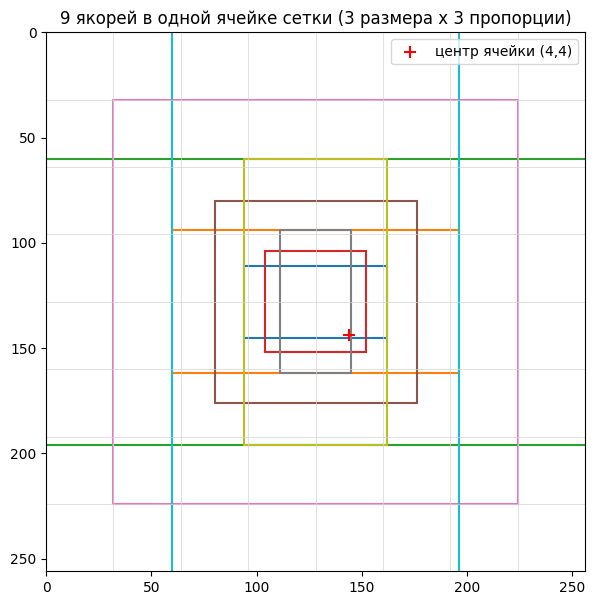

In [3]:
# Визуализация якорей в одной ячейке сетки (центральной 4,4).
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, 256); ax.set_ylim(256, 0)  # invert y, как у изображений
ax.set_aspect('equal')

# Сетка 8x8
for i in range(9):
    ax.axvline(i * 32, color='lightgray', lw=0.5)
    ax.axhline(i * 32, color='lightgray', lw=0.5)

# 9 якорей в центральной ячейке (cx=144, cy=144)
colors = plt.cm.tab10(np.linspace(0, 1, 9))
for k, anc in enumerate(center_anchors):
    x1, y1, x2, y2 = anc.tolist()
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=1.5, edgecolor=colors[k], facecolor='none')
    ax.add_patch(rect)

ax.scatter([144], [144], c='red', s=80, marker='+', label='центр ячейки (4,4)')
ax.set_title('9 якорей в одной ячейке сетки (3 размера x 3 пропорции)')
ax.legend()
plt.show()


**Попробуй сам**: измени `sizes` (например, `(16, 32, 64)` — мелкие якоря для маленьких объектов) и `aspect_ratios` (например, `(0.33, 1.0, 3.0)` — для сильно вытянутых объектов). Что произойдёт с покрытием? Когда нужны больше пропорций?

## 2. Метрика IoU — реализация вручную vs `torchvision.ops.box_iou`

**IoU (Intersection over Union)** — отношение площади пересечения к площади объединения:

$$\mathrm{IoU} = \frac{|A \cap B|}{|A \cup B|}$$

Реализуем сами и сравним с эталоном из torchvision.

In [4]:
def iou_manual(boxes_a, boxes_b):
    """Считаем IoU матрицу [N, M] для боксов в формате xyxy."""
    # Площади
    area_a = (boxes_a[:, 2] - boxes_a[:, 0]) * (boxes_a[:, 3] - boxes_a[:, 1])  # [N]
    area_b = (boxes_b[:, 2] - boxes_b[:, 0]) * (boxes_b[:, 3] - boxes_b[:, 1])  # [M]

    # Пересечение через broadcasting [N, 1, ...] vs [1, M, ...]
    x1 = torch.max(boxes_a[:, None, 0], boxes_b[None, :, 0])  # [N, M]
    y1 = torch.max(boxes_a[:, None, 1], boxes_b[None, :, 1])
    x2 = torch.min(boxes_a[:, None, 2], boxes_b[None, :, 2])
    y2 = torch.min(boxes_a[:, None, 3], boxes_b[None, :, 3])

    inter_w = (x2 - x1).clamp(min=0)
    inter_h = (y2 - y1).clamp(min=0)
    inter = inter_w * inter_h  # [N, M]

    union = area_a[:, None] + area_b[None, :] - inter
    return inter / union


# Тест на случайных боксах: 5 якорей и 3 GT
torch.manual_seed(0)
anchors_test = torch.tensor([
    [10, 10, 50, 50],   # маленький
    [30, 30, 90, 90],   # большой
    [20, 20, 60, 60],   # средний
    [70, 70, 110, 110], # отдельно
    [0, 0, 30, 30],     # в углу
], dtype=torch.float32)

gt_test = torch.tensor([
    [25, 25, 65, 65],
    [60, 60, 100, 100],
    [5, 5, 25, 25],
], dtype=torch.float32)

iou_mine = iou_manual(anchors_test, gt_test)
iou_tv = box_iou(anchors_test, gt_test)
print('Моя IoU матрица:\n', iou_mine)
print('\ntorchvision IoU:\n', iou_tv)
assert torch.allclose(iou_mine, iou_tv, atol=1e-6), 'Несовпадение!'
print('\nOK: реализации совпадают')


Моя IoU матрица:
 tensor([[0.2427, 0.0000, 0.1268],
        [0.3082, 0.2093, 0.0000],
        [0.6203, 0.0000, 0.0127],
        [0.0000, 0.3913, 0.0000],
        [0.0101, 0.0000, 0.4444]])

torchvision IoU:
 tensor([[0.2427, 0.0000, 0.1268],
        [0.3082, 0.2093, 0.0000],
        [0.6203, 0.0000, 0.0127],
        [0.0000, 0.3913, 0.0000],
        [0.0101, 0.0000, 0.4444]])

OK: реализации совпадают


**Попробуй сам**: задай два бокса, которые **не пересекаются** (например `[0,0,10,10]` и `[20,20,30,30]`). Какая IoU получится? Что это означает для лосса `1 - IoU`?

## 3. DIoU Loss — реализация и проверка против torchvision

DIoU добавляет к обычному `1 - IoU` штраф за расстояние между центрами:

$$\mathcal{L}_{\mathrm{DIoU}} = 1 - \mathrm{IoU} + \frac{d^2}{c^2}$$

где $d$ — расстояние между центрами, $c$ — диагональ выпуклой оболочки (smallest enclosing rectangle).

**Преимущество над IoU loss**: даже если боксы не пересекаются (IoU = 0), DIoU даёт градиент в сторону уменьшения расстояния между центрами — модель быстрее сходится.

In [5]:
def diou_loss_manual(pred, gt, eps=1e-7):
    """DIoU loss для пар (pred[i], gt[i]) в формате xyxy. Возвращает усреднённое значение."""
    # IoU
    inter_x1 = torch.max(pred[:, 0], gt[:, 0])
    inter_y1 = torch.max(pred[:, 1], gt[:, 1])
    inter_x2 = torch.min(pred[:, 2], gt[:, 2])
    inter_y2 = torch.min(pred[:, 3], gt[:, 3])
    inter = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)
    area_p = (pred[:, 2] - pred[:, 0]) * (pred[:, 3] - pred[:, 1])
    area_g = (gt[:, 2] - gt[:, 0]) * (gt[:, 3] - gt[:, 1])
    union = area_p + area_g - inter + eps
    iou = inter / union

    # Выпуклая оболочка
    enc_x1 = torch.min(pred[:, 0], gt[:, 0])
    enc_y1 = torch.min(pred[:, 1], gt[:, 1])
    enc_x2 = torch.max(pred[:, 2], gt[:, 2])
    enc_y2 = torch.max(pred[:, 3], gt[:, 3])
    c2 = (enc_x2 - enc_x1) ** 2 + (enc_y2 - enc_y1) ** 2 + eps

    # Расстояние между центрами
    pcx = (pred[:, 0] + pred[:, 2]) / 2
    pcy = (pred[:, 1] + pred[:, 3]) / 2
    gcx = (gt[:, 0] + gt[:, 2]) / 2
    gcy = (gt[:, 1] + gt[:, 3]) / 2
    d2 = (pcx - gcx) ** 2 + (pcy - gcy) ** 2

    return (1 - iou + d2 / c2).mean()


# Сгенерируем 100 пар случайных боксов и сравним с эталоном.
torch.manual_seed(0)
def gen_random_boxes(n):
    xy = torch.rand(n, 2) * 100
    wh = torch.rand(n, 2) * 50 + 10
    return torch.cat([xy, xy + wh], dim=1)

pred_b = gen_random_boxes(100)
gt_b = gen_random_boxes(100)

loss_mine = diou_loss_manual(pred_b, gt_b)
loss_tv = distance_box_iou_loss(pred_b, gt_b, reduction='mean')
print(f'Моя реализация DIoU loss:    {loss_mine.item():.6f}')
print(f'torchvision DIoU loss:       {loss_tv.item():.6f}')
assert torch.allclose(loss_mine, loss_tv, atol=1e-5), 'Несовпадение!'
print('OK: реализации совпадают')


Моя реализация DIoU loss:    1.259239
torchvision DIoU loss:       1.259239
OK: реализации совпадают


**Сравним поведение** обычной IoU loss и DIoU loss на двух **непересекающихся** боксах. Покажем, что IoU loss = 1.0 константно (нет градиента), а DIoU убывает с приближением центров.

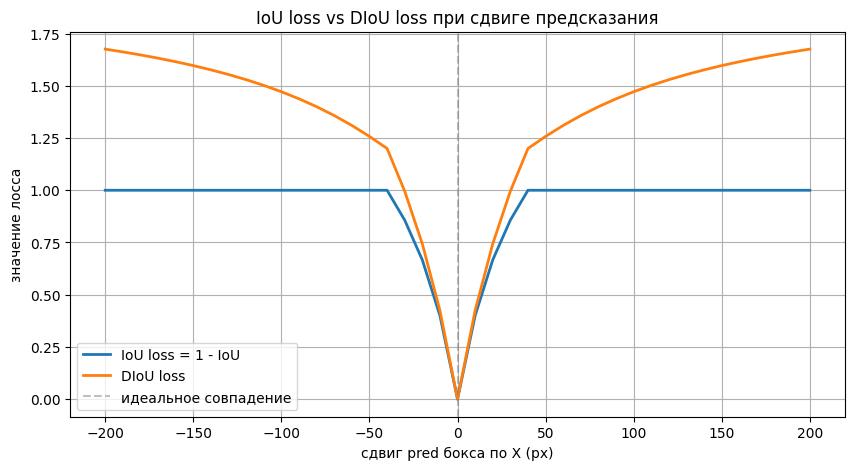

IoU loss = 1.0 при |shift| > 40 (нет пересечения) -> нулевой градиент
DIoU loss растёт с расстоянием -> модель учится двигать центры


In [6]:
# Один GT в (50,50,90,90), pred движем горизонтально
gt_fixed = torch.tensor([[50.0, 50.0, 90.0, 90.0]])
iou_losses = []
diou_losses = []
shifts = np.linspace(-200, 200, 41)
for shift in shifts:
    pred = torch.tensor([[50.0 + shift, 50.0, 90.0 + shift, 90.0]])
    iou_val = box_iou(pred, gt_fixed).item()
    iou_losses.append(1.0 - iou_val)
    diou_losses.append(distance_box_iou_loss(pred, gt_fixed, reduction='mean').item())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(shifts, iou_losses, label='IoU loss = 1 - IoU', lw=2)
ax.plot(shifts, diou_losses, label='DIoU loss', lw=2)
ax.axvline(0, color='gray', ls='--', alpha=0.5, label='идеальное совпадение')
ax.set_xlabel('сдвиг pred бокса по X (px)')
ax.set_ylabel('значение лосса')
ax.set_title('IoU loss vs DIoU loss при сдвиге предсказания')
ax.grid(); ax.legend()
plt.show()
print('IoU loss = 1.0 при |shift| > 40 (нет пересечения) -> нулевой градиент')
print('DIoU loss растёт с расстоянием -> модель учится двигать центры')


**Попробуй сам**: реализуй GIoU loss вручную (формула: $\mathrm{GIoU} = \mathrm{IoU} - \frac{|C \setminus (A \cup B)|}{|C|}$, где $C$ — выпуклая оболочка). Сравни с `generalized_box_iou(pred, gt)` (она возвращает матрицу GIoU; для лосса нужно `1 - diag(GIoU)`).

## 4. TAL (Task Alignment Learning) — демонстрация на синтетическом примере

TAL отбирает положительные якоря по совмещённой метрике:

$$t = s^\alpha \cdot u^\beta$$

где $s$ — вероятность правильного класса, $u$ — IoU, $\alpha = 6.0$, $\beta = 1.0$.

Сделаем игрушечный пример: 5 якорей и 1 GT. Покажем как считается `t` и как top-K выбирает позитивы.

In [7]:
# 5 якорей: первые 3 имеют разный IoU с GT, последние 2 — низкий IoU.
anchors_demo = torch.tensor([
    [40,  40,  90,  90 ],  # высокий IoU с GT, центр внутри
    [50,  50, 100, 100],   # высокий IoU
    [60,  60, 110, 110],   # средний IoU, центр внутри
    [10,  10,  35,  35],   # низкий IoU, центр снаружи
    [120, 120, 160, 160],  # низкий IoU, центр снаружи
], dtype=torch.float32)
gt_demo = torch.tensor([[45, 45, 105, 105]], dtype=torch.float32)
gt_label = 0  # класс 0 (один класс для простоты)

# Симулируем 'предсказания модели' (как если бы модель уже что-то училась):
# probability of class 0 для каждого якоря (мы выбрали такие числа специально)
pred_probs_class0 = torch.tensor([0.85, 0.70, 0.40, 0.20, 0.65])
# Якорь #2 имеет высокий IoU, но модель уверенно ставит ему 'не тот' класс (prob=0.40) — TAL это учтёт.
# Якорь #4 имеет низкий IoU и центр снаружи — будет отфильтрован.

alpha = 6.0
beta = 1.0
topk = 2

# Считаем IoU
u = box_iou(anchors_demo, gt_demo).squeeze(1)
s = pred_probs_class0
print(f'{"#":>2} {"anchor":<22} {"IoU":>6} {"prob_cls":>9} {"t = s^a*u^b":>12}')
for i, (anc, ui, si) in enumerate(zip(anchors_demo, u, s)):
    t_val = (si.clamp_min(1e-8)**alpha) * (ui.clamp_min(1e-8)**beta)
    print(f'{i:>2} {str(anc.int().tolist()):<22} {ui.item():>6.3f} {si.item():>9.3f} {t_val.item():>12.6f}')


 # anchor                    IoU  prob_cls  t = s^a*u^b
 0 [40, 40, 90, 90]        0.497     0.850     0.187418
 1 [50, 50, 100, 100]      0.694     0.700     0.081701
 2 [60, 60, 110, 110]      0.497     0.400     0.002035
 3 [10, 10, 35, 35]        0.000     0.200     0.000000
 4 [120, 120, 160, 160]    0.000     0.650     0.000000


In [8]:
# Применяем алгоритм TAL: center-in-GT mask + top-K
# 1) Центр каждого якоря
anchor_centers = (anchors_demo[:, :2] + anchors_demo[:, 2:]) / 2
# 2) Маска: центр внутри GT
gx1, gy1, gx2, gy2 = gt_demo[0]
inside = ((anchor_centers[:, 0] >= gx1) & (anchor_centers[:, 0] <= gx2) &
          (anchor_centers[:, 1] >= gy1) & (anchor_centers[:, 1] <= gy2))
print('Centers inside GT:', inside.tolist())

# 3) t для каждого якоря (центр снаружи -> t=0)
t = (s.clamp_min(1e-8)**alpha) * (u.clamp_min(1e-8)**beta) * inside.float()
print('t values:', [f'{x:.6f}' for x in t.tolist()])

# 4) Top-K
topk_vals, topk_idx = t.topk(topk)
print(f'\nTop-{topk} positive якоря: индексы {topk_idx.tolist()}, t-values {topk_vals.tolist()}')

print('\n--- Сравнение с обычным max-IoU assigner ---')
iou_only_idx = torch.argmax(u).item()
print(f'max-IoU выбрал бы якорь #{iou_only_idx} (IoU={u[iou_only_idx]:.3f}, prob={s[iou_only_idx]:.3f})')
print(f'TAL выбрал #{topk_idx[0].item()} (IoU={u[topk_idx[0]]:.3f}, prob={s[topk_idx[0]]:.3f})')
print('Заметь: TAL предпочитает якоря с высоким prob_cls, даже если у них чуть меньше IoU.')


Centers inside GT: [True, True, True, False, False]
t values: ['0.187418', '0.081701', '0.002035', '0.000000', '0.000000']

Top-2 positive якоря: индексы [0, 1], t-values [0.1874178797006607, 0.08170068264007568]

--- Сравнение с обычным max-IoU assigner ---
max-IoU выбрал бы якорь #1 (IoU=0.694, prob=0.700)
TAL выбрал #0 (IoU=0.497, prob=0.850)
Заметь: TAL предпочитает якоря с высоким prob_cls, даже если у них чуть меньше IoU.


**Попробуй сам**:

1. Поменяй `alpha=6.0` на `alpha=1.0` — теперь IoU важнее. Изменится ли выбор?
2. Поставь `pred_probs_class0[0] = 0.05` — главный кандидат теперь имеет низкую уверенность. Что выберет TAL?
3. Увеличь `topk` до 4 — какие 4 якоря отберутся?

## 5. NMS — фильтрация дубликатов

Сеть выдаёт тысячи кандидатов, многие из них дублируют один объект. NMS оставляет только лучшего из «соседей».

Алгоритм:

1. Сортируем по score descending.
2. Берём верхний -> добавляем в результат.
3. Удаляем всех, у кого IoU c ним >= threshold.
4. Повторяем.

In [9]:
# Симулируем 6 предсказаний: 4 окружают один объект, 2 — другой
boxes_pred = torch.tensor([
    [50,  50, 150, 150],   # объект A (главный)
    [55,  55, 155, 155],   # объект A (сдвиг 5px)
    [60,  60, 160, 160],   # объект A (сдвиг 10px)
    [45,  45, 145, 145],   # объект A (сдвиг -5px)
    [200, 200, 280, 280],  # объект B (главный)
    [205, 205, 285, 285],  # объект B (сдвиг 5px)
], dtype=torch.float32)
scores_pred = torch.tensor([0.95, 0.80, 0.60, 0.55, 0.90, 0.75])

keep = nms(boxes_pred, scores_pred, iou_threshold=0.5)
print(f'NMS оставил {len(keep)} из {len(boxes_pred)} ббоксов')
print(f'Индексы: {keep.tolist()}')
print(f'Scores: {scores_pred[keep].tolist()}')


NMS оставил 2 из 6 ббоксов
Индексы: [0, 4]
Scores: [0.949999988079071, 0.8999999761581421]


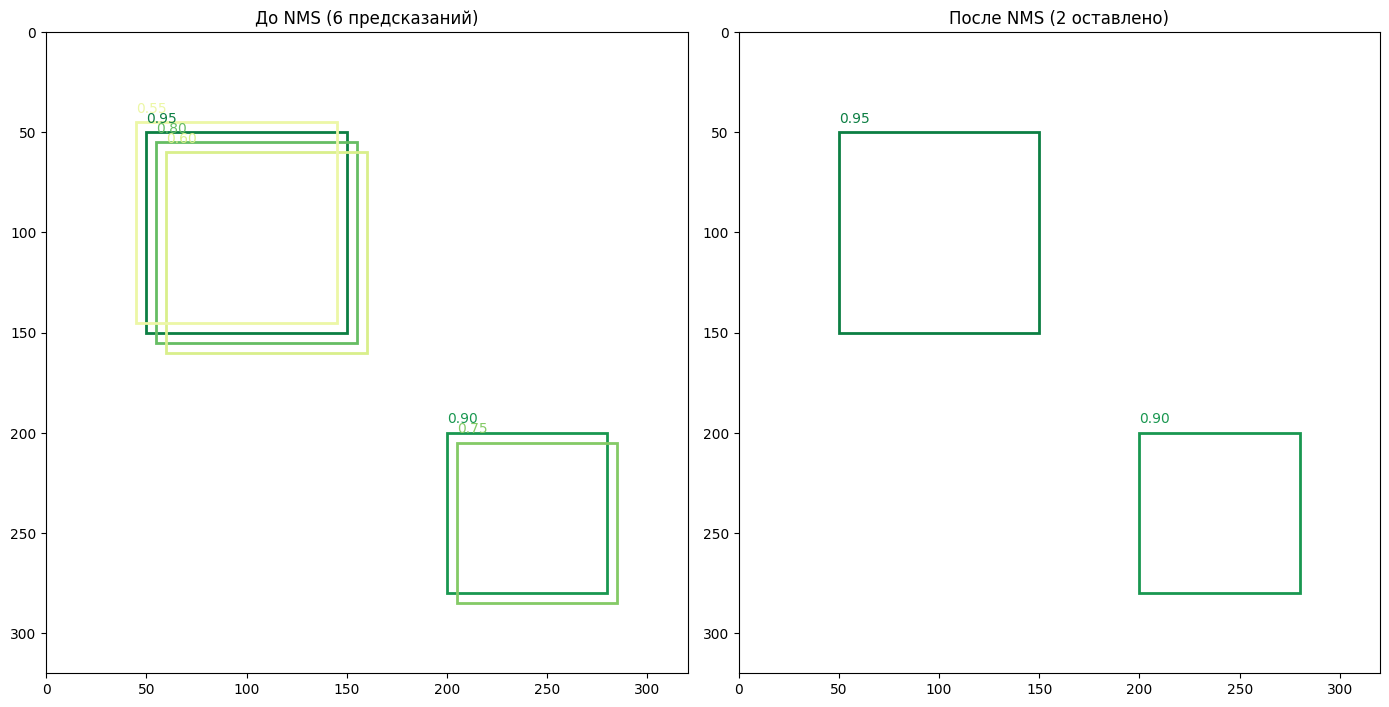

In [10]:
# Визуализация: до и после NMS
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, kept_only, title in [(axes[0], False, 'До NMS (6 предсказаний)'),
                              (axes[1], True, f'После NMS ({len(keep)} оставлено)')]:
    ax.set_xlim(0, 320); ax.set_ylim(320, 0); ax.set_aspect('equal')
    ax.set_title(title)
    indices = keep.tolist() if kept_only else list(range(len(boxes_pred)))
    cmap = plt.cm.RdYlGn
    for i in indices:
        x1, y1, x2, y2 = boxes_pred[i].tolist()
        sc = scores_pred[i].item()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=cmap(sc), facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f'{sc:.2f}', color=cmap(sc), fontsize=10)
plt.tight_layout(); plt.show()


**Попробуй сам**:

1. Сделай `iou_threshold=0.1` (очень строгий) — что произойдёт?
2. Сделай `iou_threshold=0.9` (мягкий) — оставит ли NMS дубликаты?
3. Подсказка: для **multi-class** случая используй `torchvision.ops.batched_nms(boxes, scores, idxs, iou_th)`, где `idxs` — массив class_id. NMS будет считаться отдельно по классам.

## 6. Backbone через `timm` — извлечение фич с нескольких уровней

`timm.create_model(name, features_only=True, out_indices=(...))` возвращает feature extractor, который выдаёт пирамиду фич. Параметр `out_indices` определяет, какие уровни забирать (индексация — от мелких deeper уровней).

Используем resnet18 (он легче чем resnet50, быстрее запустится в демо).

In [11]:
import timm

# resnet18 с тремя выходными уровнями: P3 (stride=8), P4 (stride=16), P5 (stride=32)
backbone = timm.create_model(
    'resnet18', pretrained=False, features_only=True, out_indices=(2, 3, 4),
)
print('Out channels на каждом уровне:', backbone.feature_info.channels())
print('Reductions (stride):', backbone.feature_info.reduction())

# Прогон: 1 картинка 256x256
x = torch.randn(1, 3, 256, 256)
feats = backbone(x)
for i, f in enumerate(feats):
    print(f'  Level {i}: {tuple(f.shape)}  (stride={backbone.feature_info.reduction()[i]})')


Out channels на каждом уровне: [128, 256, 512]
Reductions (stride): [8, 16, 32]
  Level 0: (1, 128, 32, 32)  (stride=8)
  Level 1: (1, 256, 16, 16)  (stride=16)
  Level 2: (1, 512, 8, 8)  (stride=32)


Получили **пирамиду фич** — три feature-map с уменьшающимся разрешением и растущим числом каналов.

Дальше эти фичи идут в neck (FPN/PANet), который выравнивает число каналов и пробрасывает информацию сверху вниз (top-down) и снизу вверх (bottom-up в случае PANet).

In [12]:
# Минимальная реализация FPN (top-down + lateral) для нашей пирамиды
import torch.nn as nn
import torch.nn.functional as F

class TinyFPN(nn.Module):
    def __init__(self, in_channels_list, out_channels=64):
        super().__init__()
        self.lateral = nn.ModuleList([nn.Conv2d(c, out_channels, 1) for c in in_channels_list])
        self.smooth = nn.ModuleList([nn.Conv2d(out_channels, out_channels, 3, padding=1)
                                     for _ in in_channels_list])

    def forward(self, feats):
        # Lateral 1x1 на каждом уровне
        laterals = [conv(f) for conv, f in zip(self.lateral, feats)]
        # Top-down: с самого глубокого вверх
        out = [None] * len(laterals)
        out[-1] = laterals[-1]
        for i in range(len(laterals) - 2, -1, -1):
            up = F.interpolate(out[i + 1], size=laterals[i].shape[-2:], mode='nearest')
            out[i] = laterals[i] + up
        # 3x3 сглаживание
        return [conv(x) for conv, x in zip(self.smooth, out)]

fpn = TinyFPN(in_channels_list=backbone.feature_info.channels(), out_channels=64)
fpn_feats = fpn(feats)
for i, f in enumerate(fpn_feats):
    print(f'  FPN level {i}: {tuple(f.shape)}  (теперь все имеют 64 канала)')


  FPN level 0: (1, 64, 32, 32)  (теперь все имеют 64 канала)
  FPN level 1: (1, 64, 16, 16)  (теперь все имеют 64 канала)
  FPN level 2: (1, 64, 8, 8)  (теперь все имеют 64 канала)


**Что мы получили**: три feature-map одинакового числа каналов (64) на разных разрешениях. Дальше они идут в head (`Conv2d(64, num_anchors * num_classes, 1)` для cls и `Conv2d(64, num_anchors * 4, 1)` для bbox).

**Попробуй сам**: добавь в `TinyFPN` bottom-up путь — это превратит его в PANet. Пример:
```python
# После top-down пути:
down = [None] * n_levels
down[0] = top_down_feats[0]
for i in range(n_levels - 1):
    d = nn.Conv2d(C, C, 3, stride=2, padding=1)(down[i])  # downsample x2
    down[i + 1] = d + top_down_feats[i + 1]
```


## Заключение

Что мы прошли в этом ноутбуке:

1. **Якоря** — основа anchor-based детекторов; `AnchorGenerator` генерирует их по `sizes` и `aspect_ratios`.
2. **IoU** — стандартная метрика пересечения; `torchvision.ops.box_iou` для матрицы IoU между двумя наборами.
3. **DIoU loss** — современный лосс для регрессии ббоксов; даёт градиент даже при отсутствии пересечения.
4. **TAL** — современный алгоритм label assignment; учитывает совмещённую метрику cls + IoU; решает проблемы IoU-based assigner-ов.
5. **NMS** — стандартная постобработка; `torchvision.ops.nms` для одного класса, `batched_nms` для multi-class.
6. **Backbone через timm** — `features_only=True` для пирамиды фич; FPN/PANet выравнивают каналы и пробрасывают информацию между уровнями.

**Что НЕ вошло**, но стоит изучить дальше:

- Anchor-free детекторы (FCOS, YOLOX в anchor-free режиме): вместо якорей предсказываем
  4 расстояния от каждой точки до сторон ббокса.
- DETR-семейство (RT-DETR, DINO): transformer-based, без якорей и NMS, end-to-end через bipartite matching.
- Soft-NMS, WBF — продвинутые альтернативы NMS для перекрывающихся объектов.
- Test-Time Augmentation (TTA): усреднение предсказаний на оригинале и hflip-версии для +1-2% mAP.

**Ссылки**:

- [SUMMARY.md](SUMMARY.md) — текстовый конспект с формулами и таблицами.
- [solution.ipynb](solution.ipynb) — полное решение задания (mAP=0.4068).
- [Awesome Object Detection](https://github.com/amusi/awesome-object-detection) — обзорный список статей.
